# Sanskrit → English — mBART-large-50 + LoRA (6GB GPU)
**Tuned for higher BLEU** with improved LoRA config and training.

| Improvement | Before → After |
|---|---|
| LoRA rank | r=8 → **r=16** |
| Target modules | q,v → **q,k,v,out_proj** |
| Label smoothing | 0.0 → **0.1** |
| Learning rate | 3e-4 → **1e-4** |
| Max epochs | 5 → **8** (with early stopping) |
| Generation | + no_repeat_ngram, tuned beams |

In [1]:
!pip install transformers datasets evaluate sacrebleu sentencepiece accelerate peft seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import torch, math, gc
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, DatasetDict

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
torch.cuda.empty_cache()
gc.collect()

60

## 1. Data

In [3]:
def load_parallel(sa_path, en_path):
    sa = pd.read_csv(sa_path, encoding="utf-8", engine="python", quotechar='"')
    en = pd.read_csv(en_path, encoding="utf-8", engine="python", quotechar='"')
    sa_col = [c for c in sa.columns if "Sentence" in c][0]
    en_col = [c for c in en.columns if "Sentence" in c][0]
    df = pd.DataFrame({"sanskrit": sa[sa_col].astype(str).str.strip(),
                        "english": en[en_col].astype(str).str.strip()})
    df = df[(df["sanskrit"] != "") & (df["english"] != "")]
    return df.reset_index(drop=True)

train_df = load_parallel("train_sa_10000.csv", "train_en_10000.csv")
dev_df   = load_parallel("dev_sa_1000.csv",   "dev_en_1000.csv")
test_df  = load_parallel("test_sa_1000.csv",  "test_en_1000.csv")

dataset = DatasetDict({
    "train":      Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(dev_df),
    "test":       Dataset.from_pandas(test_df),
})
print(f"Train: {train_df.shape}  Dev: {dev_df.shape}  Test: {test_df.shape}")

Train: (10000, 2)  Dev: (1000, 2)  Test: (1000, 2)


## 2. Model — mBART-large-50 + LoRA (Enhanced)
- **r=16** for more capacity (was r=8)
- **4 target modules** instead of 2 — captures richer attention patterns

In [4]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import LoraConfig, get_peft_model, TaskType

MODEL_NAME = "facebook/mbart-large-50-many-to-many-mmt"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.src_lang = "sa_IN"
tokenizer.tgt_lang = "en_XX"

model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16)

# Enhanced LoRA — more rank + more target modules
lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=16,                                              # Doubled from 8
    lora_alpha=32,                                     # 2× rank
    lora_dropout=0.05,                                 # Reduced dropout
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],  # All 4 attn projections
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

model.gradient_checkpointing_enable()
model.enable_input_require_grads()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

trainable params: 4,718,592 || all params: 615,598,080 || trainable%: 0.7665
Device: cuda
GPU: 15.8 GB
Allocated: 1.24 GB


## 3. Tokenization

In [5]:
MAX_LEN = 64

def preprocess(examples):
    model_inputs = tokenizer(examples["sanskrit"], max_length=MAX_LEN, truncation=True)
    labels = tokenizer(text_target=examples["english"], max_length=MAX_LEN, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized = dataset.map(preprocess, batched=True, remove_columns=["sanskrit", "english"])

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [6]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model, padding=True)

## 4. Training (Tuned for BLEU)
- **Label smoothing 0.1** — prevents overconfident predictions
- **LR 1e-4** — more stable than 3e-4 for LoRA
- **8 epochs + early stopping** — more time to converge

In [7]:
import evaluate

bleu_m = evaluate.load("sacrebleu")
chrf_m = evaluate.load("chrf")

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    dec_p = [p.strip() for p in tokenizer.batch_decode(preds, skip_special_tokens=True)]
    dec_l = [l.strip() for l in tokenizer.batch_decode(labels, skip_special_tokens=True)]
    refs = [[l] for l in dec_l]
    return {
        "bleu": bleu_m.compute(predictions=dec_p, references=refs)["score"],
        "chrf": chrf_m.compute(predictions=dec_p, references=refs)["score"],
    }

In [8]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, EarlyStoppingCallback

training_args = Seq2SeqTrainingArguments(
    output_dir="./mbart_lora_v2",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-4,                # Stable LR for LoRA
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=8,                # More epochs (early stopping will halt if needed)
    weight_decay=0.01,
    warmup_ratio=0.1,
    label_smoothing_factor=0.1,        # Smooths targets → better generalization
    optim="adafactor",
    predict_with_generate=True,
    generation_max_length=64,
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="bleu",
    greater_is_better=True,
    save_total_limit=2,
    gradient_checkpointing=True,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],  # patience=3 for stability
)
print("Trainer Ready")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer Ready


In [9]:
torch.cuda.empty_cache()
trainer.train()

Epoch,Training Loss,Validation Loss,Bleu,Chrf
1,28.820432,3.503962,12.385184,34.085274
2,27.221907,3.347522,15.329653,37.361031
3,26.171741,3.276964,17.044559,39.383010
4,25.639866,3.231489,18.122366,40.268609
5,25.564199,3.207185,18.703696,40.854576
6,24.524517,3.188709,19.044815,41.267632
7,24.993857,3.182711,19.333772,41.572621
8,24.407825,3.178985,19.137244,41.389582


TrainOutput(global_step=5000, training_loss=26.362452416992188, metrics={'train_runtime': 15874.7001, 'train_samples_per_second': 5.039, 'train_steps_per_second': 0.315, 'total_flos': 5939910543900672.0, 'train_loss': 26.362452416992188, 'epoch': 8.0})

## 5. Evaluation

In [12]:
!pip install bert_score

In [13]:
bertscore_m = evaluate.load("bertscore")
preds = trainer.predict(tokenized["test"])
dec_preds = tokenizer.batch_decode(preds.predictions, skip_special_tokens=True)
dec_labels = test_df["english"].tolist()

bert = bertscore_m.compute(predictions=dec_preds, references=dec_labels, lang="en")
print(f"BERTScore F1: {np.mean(bert['f1']):.4f}")

print("\n--- Sample Translations ---")
for i in range(5):
    print(f"\nSanskrit:  {test_df['sanskrit'].iloc[i]}")
    print(f"Reference: {test_df['english'].iloc[i]}")
    print(f"Predicted: {dec_preds[i]}")

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore F1: 0.9192

--- Sample Translations ---

Sanskrit:  एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।
Reference: Eclipse also helps the programmer to find out errors.
Predicted: Eclipse helps and detects errors in the program.

Sanskrit:  विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्रे लिखितं तथैवास्माभिरपि विश्वासजनकम् आत्मानं प्राप्य विश्वासः क्रियते तस्माच्च वचांसि भाष्यन्ते।
Reference: "We having the same spirit of faith, according as it is written, I believed, and therefore have I spoken; we also believe, and therefore speak;"
Predicted: "For as it is written in the Scriptures, even as the faithful also speak, even as the faithful also speak, when they receive faith from the Spirit."

Sanskrit:  तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं 'Cancel' इत्यस्योपरि नुदामि।
Reference: Then it will automatically begin searching for drivers. I will click on Cancel.
Predicted: It also searches for the driver. I click on Cancel.

Sanskrit:  सर्वेभ्यः इटरेशन्-अर्थम्

## 6. Visualizations
### 6a. Sentence Embedding t-SNE

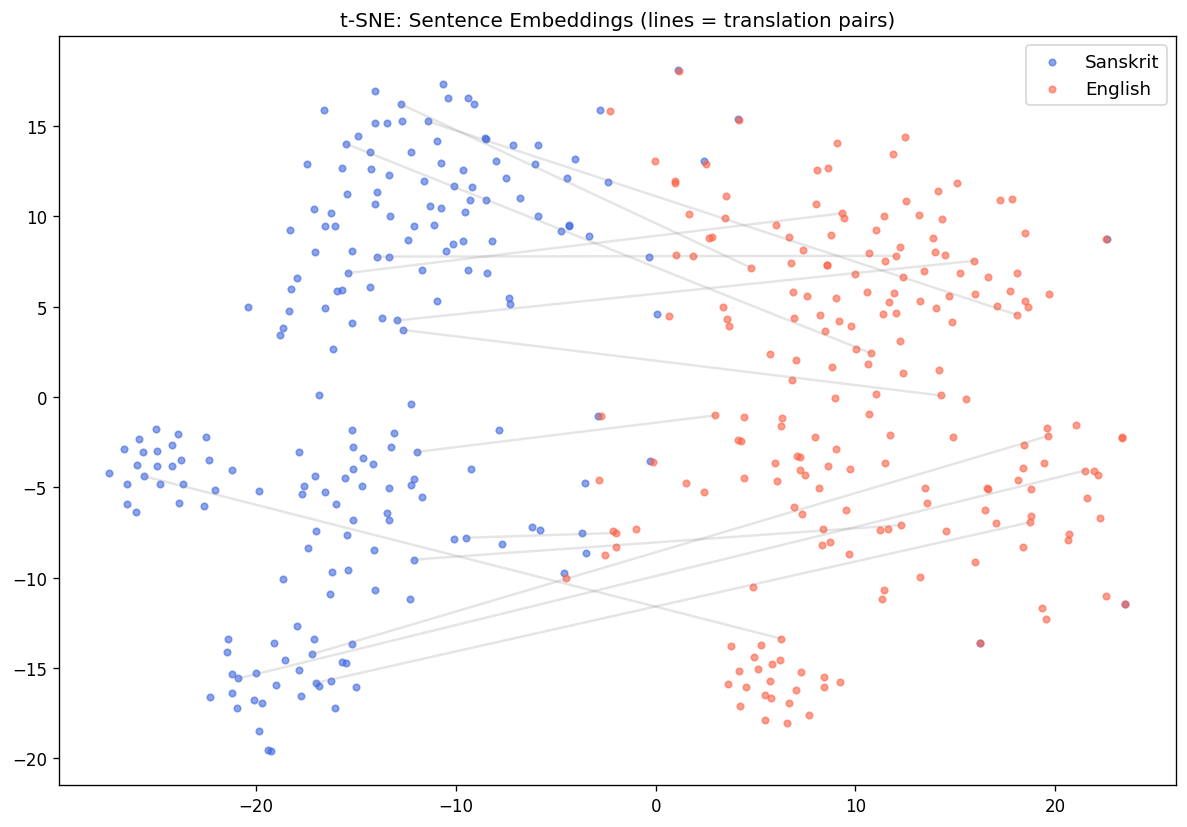

In [14]:
from sklearn.manifold import TSNE

def get_embeddings(texts, batch_size=8):
    base = model.base_model.model if hasattr(model, 'base_model') else model
    encoder = base.get_encoder()
    embs = []
    for i in range(0, len(texts), batch_size):
        inp = tokenizer(texts[i:i+batch_size], return_tensors="pt",
                        padding=True, truncation=True, max_length=MAX_LEN).to(device)
        with torch.no_grad():
            out = encoder(input_ids=inp.input_ids, attention_mask=inp.attention_mask)
            mask = inp.attention_mask.unsqueeze(-1).float()
            emb = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
            embs.append(emb.cpu().float().numpy())
        torch.cuda.empty_cache()
    return np.vstack(embs)

N = 200
sa_emb = get_embeddings(test_df["sanskrit"][:N].tolist())
en_emb = get_embeddings(test_df["english"][:N].tolist())

pts = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(
    np.vstack([sa_emb, en_emb])
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(pts[:N,0], pts[:N,1], c="royalblue", alpha=0.6, s=15, label="Sanskrit")
ax.scatter(pts[N:,0], pts[N:,1], c="tomato",    alpha=0.6, s=15, label="English")
for i in range(0, N, N//15):
    ax.plot([pts[i,0], pts[N+i,0]], [pts[i,1], pts[N+i,1]], "gray", alpha=0.2)
ax.legend(fontsize=11)
ax.set_title("t-SNE: Sentence Embeddings (lines = translation pairs)")
plt.tight_layout(); plt.show()

### 6c. Word Embedding Cosine Similarity

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2319 (\N{DEVANAGARI LETTER E}) missing from current font.
  fig.canvas.draw()
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.draw()
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from current font.
  fig.canvas.draw()
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from current font.
  fig.canvas.draw()
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2354 (\N{DEVANAGARI LETTER LA}) missing from current font.
  fig.canvas.draw()
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/seaborn/

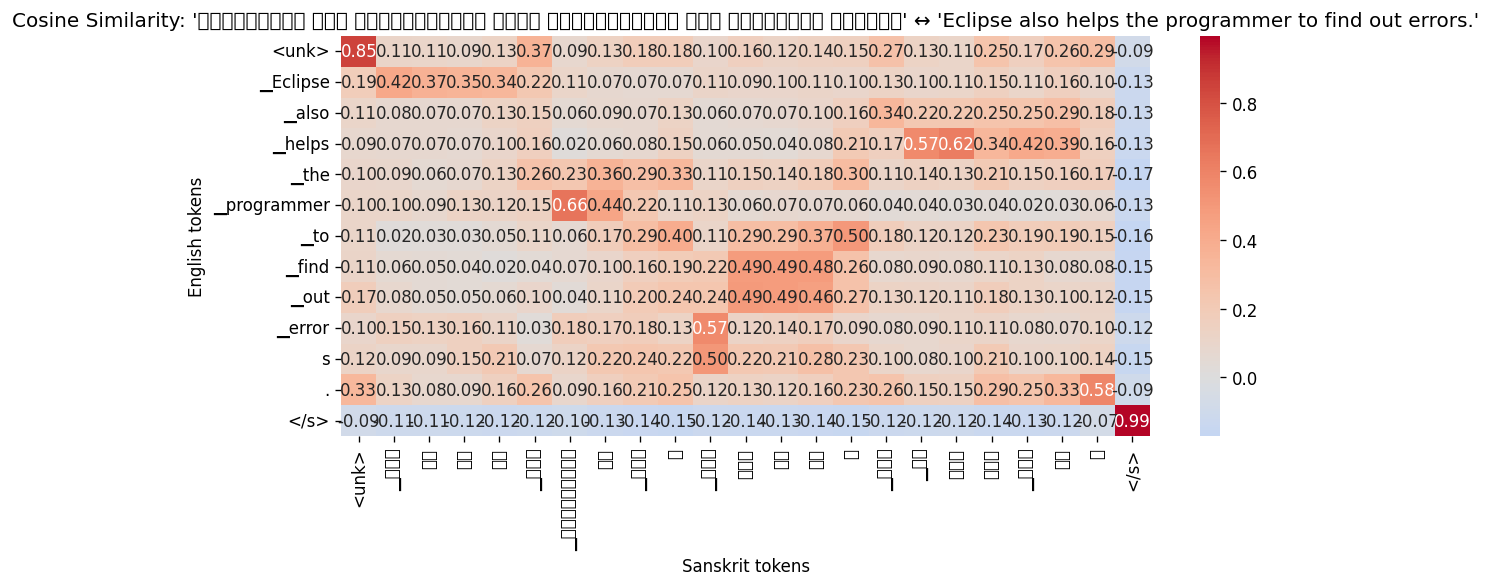

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2357 (\N{DEVANAGARI LETTER VA}) missing from current font.
  fig.canvas.draw()
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.draw()
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2367 (\N{DEVANAGARI VOWEL SIGN I}) missing from current font.
  fig.canvas.draw()
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from current font.
  fig.canvas.draw()
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from current font.
  fig.canvas.draw()
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sea

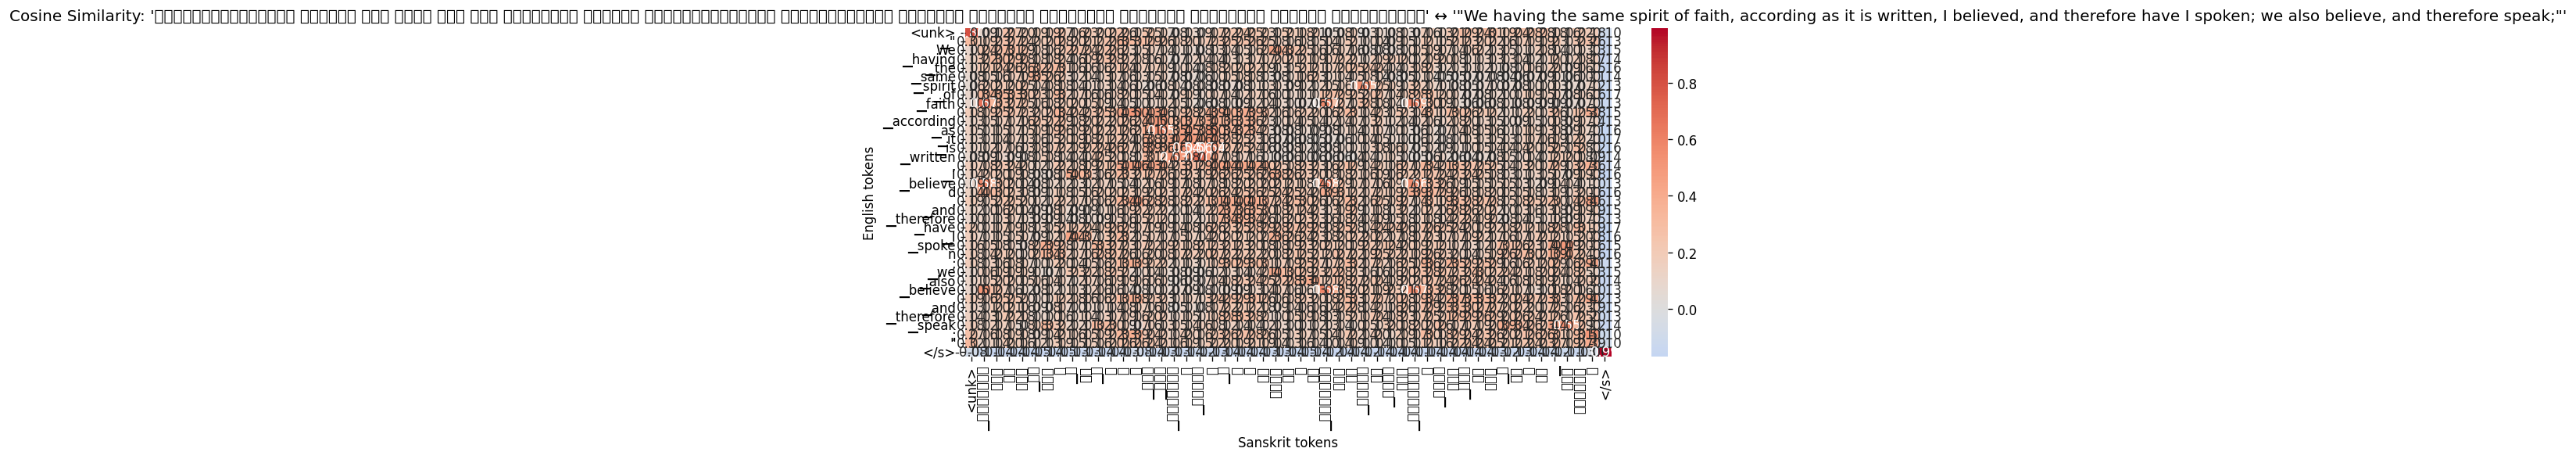

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

def plot_word_sim(sa_text, en_text):
    base = model.base_model.model if hasattr(model, 'base_model') else model
    encoder = base.get_encoder()
    sa_inp = tokenizer(sa_text, return_tensors="pt").to(device)
    en_inp = tokenizer(en_text, return_tensors="pt").to(device)
    with torch.no_grad():
        sa_e = encoder(input_ids=sa_inp.input_ids).last_hidden_state[0].cpu().float().numpy()
        en_e = encoder(input_ids=en_inp.input_ids).last_hidden_state[0].cpu().float().numpy()
    sim = cosine_similarity(en_e, sa_e)
    sa_tok = tokenizer.convert_ids_to_tokens(sa_inp.input_ids[0])
    en_tok = tokenizer.convert_ids_to_tokens(en_inp.input_ids[0])
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(sim, xticklabels=sa_tok, yticklabels=en_tok,
                cmap="coolwarm", center=0, ax=ax, annot=True, fmt=".2f")
    ax.set_xlabel("Sanskrit tokens"); ax.set_ylabel("English tokens")
    ax.set_title(f"Cosine Similarity: '{sa_text}' ↔ '{en_text}'")
    plt.tight_layout(); plt.show()

plot_word_sim(test_df["sanskrit"].iloc[0], test_df["english"].iloc[0])
plot_word_sim(test_df["sanskrit"].iloc[1], test_df["english"].iloc[1])

## 7. Save & Inference

In [17]:
model.save_pretrained("./final_mbart_lora_v2")
tokenizer.save_pretrained("./final_mbart_lora_v2")
print("LoRA adapter saved to ./final_mbart_lora_v2")

LoRA adapter saved to ./final_mbart_lora_v2


In [18]:
def translate(text, num_beams=5):
    inp = tokenizer(text, return_tensors="pt").to(device)
    gen = model.generate(
        **inp, num_beams=num_beams, max_length=MAX_LEN,
        forced_bos_token_id=tokenizer.lang_code_to_id["en_XX"],
        length_penalty=1.0,
        no_repeat_ngram_size=3,
    )
    return tokenizer.decode(gen[0], skip_special_tokens=True)

examples = [
    "सा फलानि खादति।",
    "गुरुः छात्रान् एकवारं पाठयति ।",
    "वयं  Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।",
]
for sa in examples:
    print(f"Sanskrit: {sa}")
    print(f"English:  {translate(sa)}\n")

Sanskrit: सा फलानि खादति।
English:  It eats fruits.

Sanskrit: गुरुः छात्रान् एकवारं पाठयति ।
English:  Guru teaches to the students once a day.

Sanskrit: वयं  Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।
English:  We will select the Colors option with notation.

